# Week 1: Polynomial and Interaction Terms

This notebook uses the B2B CRM dataset to look at revenue with polynomial and interaction terms.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
import os
import kagglehub
path = kagglehub.dataset_download( "ezogngrd/synthetic-b2b-crm-and-marketing-data")

print(path)
print(os.listdir(path))
import pandas as pd
import os

df_b2b = pd.read_csv(os.path.join(path, "companies_clean_734.csv"))
df_b2b.head()

/Users/riverocel/.cache/kagglehub/datasets/ezogngrd/synthetic-b2b-crm-and-marketing-data/versions/1
['employees_noisy_5234.csv', 'companies_clean_734.csv', 'companies_noisy_734.csv', 'employees_clean_5234.csv', 'employees_with_company_sample.csv']


,Company_ID,Industry,Company_Size,Annual_Revenue (M₺),Marketing_Spend (K₺),Campaign_Type,Leads_Generated,Conversion_Rate (%),Region,District,Last_Product_1,Last_Product_2,Frequency_of_Purchase,Days_Since_Last_Purchase,Contract_Status,Total_Purchases_Last_Year,Payment_Behavior,Preferred_Channel,Sales_Rep
0,C0001,"Mining, metals & minerals",Medium,17.3,33,SEM,12,0.9,Adana,Ceyhan,Process safety & automation,Valves,Monthly,6,Pending,15,On-time,Sales Rep,E**** T*******
1,C0002,Space,Small,4.9,12,Content Marketing,4,1.2,Sakarya,Arifiye,Energy storage systems,Actuators & motion control,Occasionally,310,Active,0,On-time,Sales Rep,D**** S*******
2,C0003,Buildings,Small,1.1,11,Content Marketing,9,1.1,Ankara,Etimesgut,Lighting & controls,Conduit & cable management,Quarterly,63,Active,4,Occasional delay,Sales Rep,B**** K*******
3,C0004,Oil & gas,Small,5.7,29,Trade Show,9,0.4,Eskisehir,Tepebasi,Medium-voltage power systems,Process safety & automation,Monthly,17,Active,8,On-time,Sales Rep,A**** Y*******
4,C0005,Oil & gas,Small,8.3,23,Trade Show,11,0.5,Zonguldak,Kozlu,Medium-voltage power systems,Fuel systems & emissions,Quarterly,93,Active,3,On-time,Sales Rep,C**** D*******


In [3]:
# Clean column names
df_b2b.columns = (
    df_b2b.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("(", "")
    .str.replace(")", "")
    .str.replace("%", "pct")
    .str.replace("₺", "")
)

print(df_b2b.columns)

Index(['company_id', 'industry', 'company_size', 'annual_revenue_m',
       'marketing_spend_k', 'campaign_type', 'leads_generated',
       'conversion_rate_pct', 'region', 'district', 'last_product_1',
       'last_product_2', 'frequency_of_purchase', 'days_since_last_purchase',
       'contract_status', 'total_purchases_last_year', 'payment_behavior',
       'preferred_channel', 'sales_rep'],
      dtype='object')


In [4]:
target = "annual_revenue_m"
features = [
    "marketing_spend_k",
    "leads_generated",
    "conversion_rate_pct",
    "days_since_last_purchase",
    "total_purchases_last_year",
    "company_size",
    "industry",
    "campaign_type",
    "preferred_channel"
]

In [5]:
data = df_b2b[[target] + features].dropna()

In [6]:
X = data[features]
y = data[target]

categorical_features = [
    "company_size",
    "industry",
    "campaign_type",
    "preferred_channel"
]

continuous_features = [
    "marketing_spend_k",
    "leads_generated",
    "conversion_rate_pct",
    "days_since_last_purchase",
    "total_purchases_last_year"
]

In [7]:
df_b2b["spend_x_conversion"] = (
    df_b2b["marketing_spend_k"] * df_b2b["conversion_rate_pct"]
)

In [8]:
features_interaction = [
    "marketing_spend_k",
    "conversion_rate_pct",
    "spend_x_conversion",
    "leads_generated",
    "days_since_last_purchase",
    "total_purchases_last_year"
]

In [9]:
import statsmodels.formula.api as smf

In [10]:
# Interaction model
data["marketing_spend_squared"] = (
    data["marketing_spend_k"] ** 2
)

model2 = smf.ols("""
annual_revenue_m ~
marketing_spend_k +
marketing_spend_squared +
leads_generated +
conversion_rate_pct +
days_since_last_purchase +
total_purchases_last_year
""", data=data).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:       annual_revenue_m   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     74.15
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.06e-72
Time:                        21:42:53   Log-Likelihood:                -3416.2
No. Observations:                 734   AIC:                             6846.
Df Residuals:                     727   BIC:                             6879.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

here we are looking at the ols regression for linear and non linear trends within our variables. for regular marketing spend the coefficient came out negative and the squared version was positive with a highly significant p value. That means when we are spending higher levels of marketing spend the effect of spending will increase revenue but in lower spendings it will decrease the revenue, having a u shaped relationship.

In [11]:
# Interaction: marketing spend x conversion rate
data["spend_x_conversion"] = (
    data["marketing_spend_k"] *
    data["conversion_rate_pct"]
)

model3 = smf.ols("""
annual_revenue_m ~
marketing_spend_k +
conversion_rate_pct +
spend_x_conversion +
leads_generated +
days_since_last_purchase +
total_purchases_last_year
""", data=data).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:       annual_revenue_m   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     50.58
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.91e-52
Time:                        21:42:53   Log-Likelihood:                -3463.4
No. Observations:                 734   AIC:                             6941.
Df Residuals:                     727   BIC:                             6973.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [12]:
# FULL MODEL WITH INTERACTIONS AND CATEGORICAL VARIABLES
model4 = smf.ols("""
annual_revenue_m ~
marketing_spend_k +
leads_generated +
conversion_rate_pct +
C(company_size) +
C(industry) +
C(campaign_type) +
C(preferred_channel)
""", data=data).fit()

print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:       annual_revenue_m   R-squared:                       0.881
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     217.8
Date:                Sun, 28 Jun 2026   Prob (F-statistic):          5.53e-308
Time:                        21:42:53   Log-Likelihood:                -2811.5
No. Observations:                 734   AIC:                             5673.
Df Residuals:                     709   BIC:                             5788.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
#VIF ANALYSIS
vif_data = data[[
    "marketing_spend_k",
    "leads_generated",
    "conversion_rate_pct",
    "days_since_last_purchase",
    "total_purchases_last_year"
]]

X = sm.add_constant(vif_data)

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_df)

                    Variable        VIF
0                      const  26.175986
1          marketing_spend_k   1.023213
2            leads_generated   1.018695
3        conversion_rate_pct   1.002740
4   days_since_last_purchase   2.413679
5  total_purchases_last_year   2.416790


## Paper Visuals

These plots help show the main Week 1 idea visually: revenue does not move in a perfectly straight line with marketing spend, and company size matters a lot.

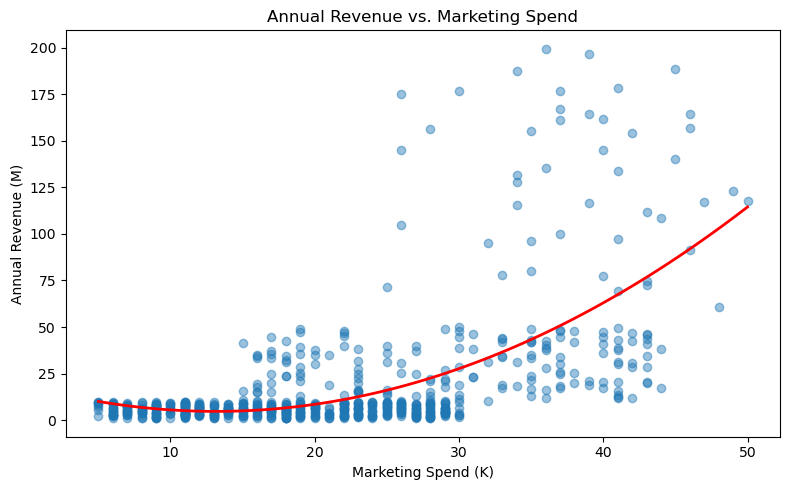

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(
    data["marketing_spend_k"],
    data["annual_revenue_m"],
    alpha=0.45
)

spend_line = np.linspace(
    data["marketing_spend_k"].min(),
    data["marketing_spend_k"].max(),
    100
)
poly_line = np.poly1d(np.polyfit(
    data["marketing_spend_k"],
    data["annual_revenue_m"],
    2
))

plt.plot(spend_line, poly_line(spend_line), color="red", linewidth=2)
plt.xlabel("Marketing Spend (K)")
plt.ylabel("Annual Revenue (M)")
plt.title("Annual Revenue vs. Marketing Spend")
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

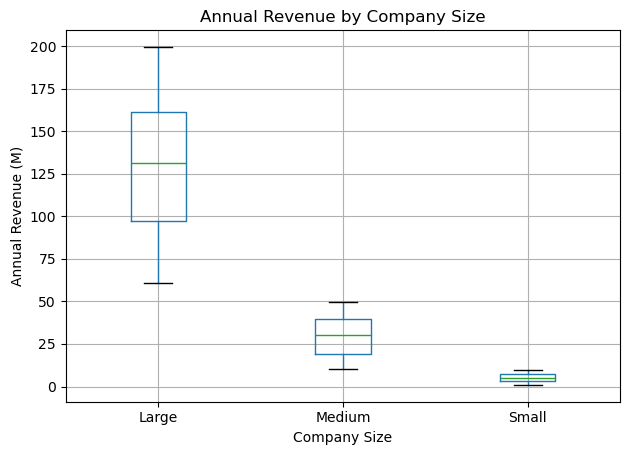

In [15]:
plt.figure(figsize=(7, 5))
data.boxplot(column="annual_revenue_m", by="company_size")
plt.suptitle("")
plt.title("Annual Revenue by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Annual Revenue (M)")
plt.tight_layout()
plt.show()